# Employee Attrition Prediction and Retention Analysis

## Import Libraries

In [330]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier

## Upload Dataset

In [331]:
df = pd.read_csv("Employee_Attrition_Analysis.csv")

## Dataset Overview

The first five observations were examined to understand the structure of the dataset, variable names, and data format before conducting further analysis.

In [332]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

The dataset contains 1,470 employee records and 35 variables, including both numerical and categorical features.

In [334]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Descriptive statistics were calculated to summarize the distribution of numerical variables.

## Missing Value Analysis

In [335]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Missing value analysis revealed that no variables contain null observations.

## Target Variable Analysis

In [336]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [337]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

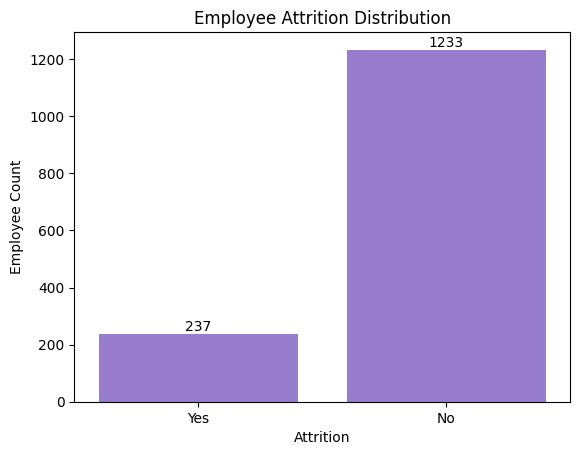

In [338]:
ax = sns.countplot(
    data=df,
    x="Attrition",
    color="mediumpurple"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()+10
        ),
        ha="center"
    )

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.show()

The distribution of the target variable shows that employee attrition is relatively uncommon within the organization. Approximately 83.9% of employees remained with the company, while only 16.1% left. This indicates a class imbalance problem, which should be considered during model development to ensure accurate identification of employees at risk of leaving.

## Explatory Analysis

### Demographic Analysis

<Axes: xlabel='Attrition', ylabel='Age'>

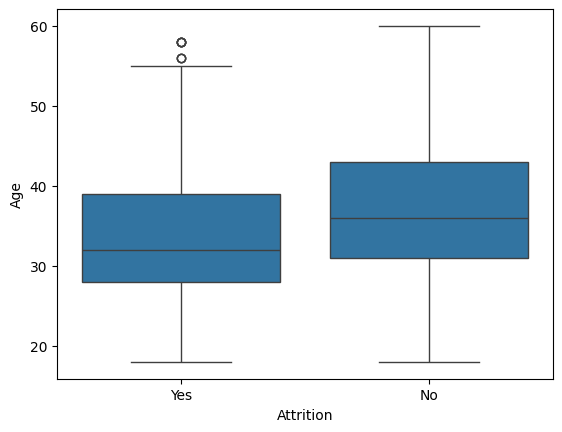

In [339]:
sns.boxplot(
    x="Attrition",
    y="Age",
    data=df
)

The age distribution suggests that employees who left the company tend to be younger than those who stayed. This finding may indicate that younger employees are more likely to explore alternative career opportunities and exhibit higher job mobility.

In [340]:
pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


Attrition rates were relatively similar across genders, with only a small difference observed between male and female employees. This suggests that gender does not appear to be a major factor influencing employee turnover.

In [341]:
pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


Single employees exhibited the highest attrition rate (25.5%), substantially exceeding the rates observed among married and divorced employees. This may indicate that employees with fewer family commitments are more willing to change jobs and pursue new opportunities.

### Work-Life Aanalysis

<Axes: xlabel='Attrition', ylabel='DistanceFromHome'>

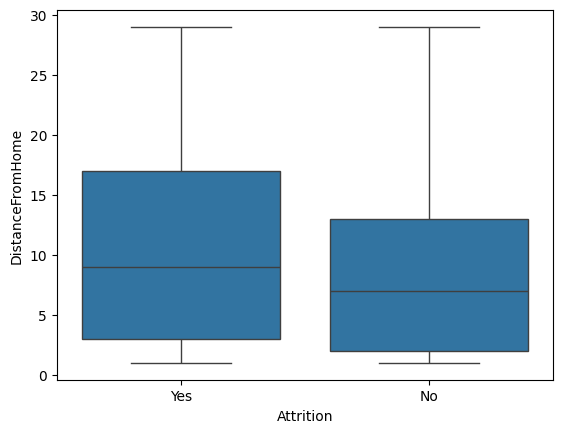

In [342]:
sns.boxplot(
    x="Attrition",
    y="DistanceFromHome",
    data=df
)

Employees who left the company tended to live slightly farther from their workplace compared to those who stayed. However, the overlap between the distributions suggests that commuting distance alone is not a strong predictor of employee attrition.

In [343]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Employees who worked overtime showed a substantially higher attrition rate (30.5%) compared to those who did not work overtime (10.4%). This finding suggests that excessive workload and work-life imbalance may significantly contribute to employee turnover.

In [344]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


Employees who worked overtime showed a substantially higher attrition rate (30.5%) compared to those who did not work overtime (10.4%). This finding suggests that excessive workload and work-life imbalance may significantly contribute to employee turnover.

### Compensation Analysis

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

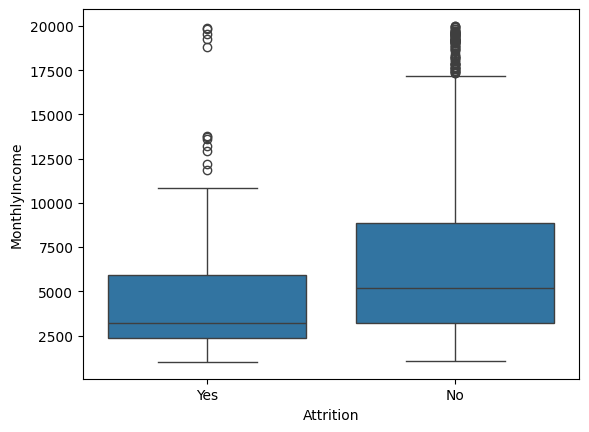

In [345]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

Employees who left the company generally earned lower monthly incomes compared to those who stayed. The median monthly income of employees with attrition was noticeably lower, suggesting that compensation may play an important role in employee retention.

In [346]:
pd.crosstab(
    df["StockOptionLevel"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
StockOptionLevel,,
0,75.594295,24.405705
1,90.604027,9.395973
2,92.405063,7.594937
3,82.352941,17.647059


### Job Satisfaction Analysis

In [347]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Employee attrition decreased as job satisfaction increased. Employees with the lowest job satisfaction level exhibited the highest attrition rate (22.8%), while employees with the highest satisfaction level showed the lowest attrition rate (11.3%). This suggests that improving employee satisfaction may contribute significantly to reducing turnover.

In [348]:
pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


Employees with lower environment satisfaction levels were substantially more likely to leave the company. The attrition rate dropped from 25.4% among employees with the lowest satisfaction level to approximately 13.5% among those with the highest satisfaction level. This indicates that workplace environment plays an important role in employee retention.

In [349]:
pd.crosstab(
    df["RelationshipSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
RelationshipSatisfaction,,
1,79.347826,20.652174
2,85.148515,14.851485
3,84.531590,15.468410
4,85.185185,14.814815


Employees with lower relationship satisfaction levels experienced higher attrition rates. Although the effect was less pronounced than job satisfaction and environment satisfaction, the results suggest that workplace relationships may still influence employee retention.

### Special Group Analysis

A special employee segment was created to investigate employees who received above-median salaries and reported relatively high job satisfaction levels. Despite favorable compensation and satisfaction conditions, a subset of these employees still left the company. This analysis aims to identify additional factors that may contribute to attrition among otherwise satisfied employees.

In [350]:
special_group = df[
    (df["MonthlyIncome"] > df["MonthlyIncome"].median()) &
    (df["JobSatisfaction"] >= 3)
]

In [351]:
special_group["Attrition"].value_counts()

Attrition
No     410
Yes     41
Name: count, dtype: int64

In [352]:
special_group["Attrition"].value_counts(normalize=True)*100

Attrition
No     90.909091
Yes     9.090909
Name: proportion, dtype: float64

Within this group, only 9.1% of employees left the company, compared to the overall attrition rate of 16.1%. This finding suggests that higher compensation and job satisfaction are associated with improved employee retention. However, the presence of 41 employees who still left the company indicates that additional factors beyond salary and satisfaction may influence turnover decisions.

In [353]:
special_attrition = special_group[
    special_group["Attrition"] == "Yes"
]

special_attrition.shape

(41, 35)

In [354]:
pd.crosstab(
    special_attrition["OverTime"],
    special_attrition["Attrition"]
)

Attrition,Yes
OverTime,
No,20
Yes,21


Among high-income and satisfied employees who left the company, overtime was almost evenly distributed. This suggests that overtime alone may not fully explain attrition within this specific employee segment.

In [355]:
pd.crosstab(
    special_attrition["BusinessTravel"],
    special_attrition["Attrition"]
)

Attrition,Yes
BusinessTravel,
Non-Travel,1
Travel_Frequently,11
Travel_Rarely,29


Most of the attrition cases in this specific group were observed among employees who travel for business. Only one attrition case was recorded among employees who do not travel.

In [356]:
special_attrition["DistanceFromHome"].describe()

count    41.000000
mean     11.365854
std       8.389744
min       1.000000
25%       4.000000
50%       9.000000
75%      16.000000
max      27.000000
Name: DistanceFromHome, dtype: float64

Employees in this segment who left the company lived an average of approximately 11 distance units from their workplace, suggesting that commuting distance may have contributed to turnover decisions for some employees.

In [357]:
special_attrition["YearsSinceLastPromotion"].describe()

count    41.000000
mean      3.902439
std       4.537647
min       0.000000
25%       0.000000
50%       2.000000
75%       7.000000
max      15.000000
Name: YearsSinceLastPromotion, dtype: float64

Although these employees received relatively high salaries and reported satisfactory job experiences, many had not received a promotion for several years. The average time since the last promotion was approximately four years, suggesting that limited career progression opportunities may have influenced attrition decisions.

In [358]:
special_attrition["NumCompaniesWorked"].describe()

count    41.000000
mean      3.341463
std       2.679643
min       0.000000
25%       1.000000
50%       3.000000
75%       6.000000
max       9.000000
Name: NumCompaniesWorked, dtype: float64

Employees in this segment had worked for an average of more than three companies during their careers. This may indicate a greater tendency toward job mobility and a lower likelihood of remaining with a single employer for extended periods.

The special group analysis revealed that even highly paid and satisfied employees may leave the company due to factors beyond compensation and job satisfaction. Limited promotion opportunities, business travel requirements, commuting distance, and individual career mobility patterns appear to contribute to attrition decisions among this employee segment.

### Job Role Analysis

In [359]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

jobrole_attrition = jobrole_attrition.sort_values(
    by="Yes",
    ascending=False
)

jobrole_attrition

Attrition,No,Yes
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


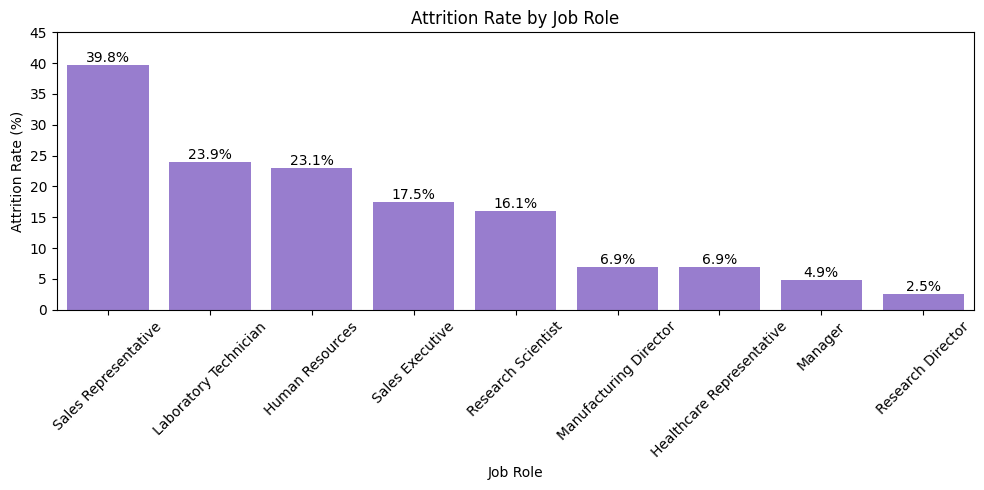

In [360]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition["Yes"],
    color="mediumpurple"
    
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.ylim(0, 45)

plt.xticks(rotation=45)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.title("Attrition Rate by Job Role")

plt.tight_layout()
plt.show()

Attrition rates varied considerably across job roles. Sales Representatives exhibited the highest attrition rate (39.8%), followed by Laboratory Technicians (23.9%) and Human Resources employees (23.1%). In contrast, Research Directors (2.5%) and Managers (4.9%) showed the lowest attrition rates. These findings suggest that turnover risk differs substantially by role and may be influenced by job-specific working conditions, career opportunities, and workload expectations.

### Data Preprocessing

#### 1. Target Variable Encoding

Before building machine learning models, the dataset was preprocessed to prepare the features for training. The target variable was converted into a numerical format, non-informative variables were removed, and categorical variables were transformed using one-hot encoding. These steps ensure that the data is suitable for machine learning algorithms.

In [361]:
df["AttritionNumeric"] = df["Attrition"].map({
    "No" : 0,
    "Yes" : 1 
})

df[["Attrition", "AttritionNumeric"]].head()

,Attrition,AttritionNumeric
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


The target variable was converted into a binary numerical format where "No" was mapped to 0 and "Yes" was mapped to 1.

#### 2. Remove Non-Informative Variables

In [362]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
AttritionNumeric               2
Department                     3
MaritalStatus                  3
BusinessTravel                 3
RelationshipSatisfaction       4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
StockOptionLevel               4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age       

In [363]:
df = df.drop(
    [
    "Attrition",
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
],
    axis=1
    )


In [364]:
df.shape

(1470, 31)

In [365]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNumeric
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,2,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,4,1,6,3,3,2,2,2,2,0


Non-informative variables, including employee identifiers and constant-value features, were removed from the dataset. The original target variable was also dropped after creating its numerical representation to avoid redundancy.

#### 3. One-Hot Encoding

In [366]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols


Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [367]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [368]:
df_encoded.shape

(1470, 45)

In [369]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   Education                          1470 non-null   int64
 4   EnvironmentSatisfaction            1470 non-null   int64
 5   HourlyRate                         1470 non-null   int64
 6   JobInvolvement                     1470 non-null   int64
 7   JobLevel                           1470 non-null   int64
 8   JobSatisfaction                    1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  MonthlyRate                        1470 non-null   int64
 11  NumCompaniesWorked                 1470 non-null   int64
 12  PercentSalaryHike   

Categorical variables were transformed into numerical format using one-hot encoding. The first category of each variable was dropped to avoid multicollinearity and reduce redundancy in the feature set.

Ordinal variables such as Education, Job Satisfaction, and Work-Life Balance were preserved in their original numerical form because their values represent meaningful ordered levels. Only nominal categorical variables were transformed using one-hot encoding.

### Train-Test Split

In [370]:
X = df_encoded.drop("AttritionNumeric", axis=1)
y = df_encoded["AttritionNumeric"]

In [371]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [372]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

(1176, 44)
(294, 44)
AttritionNumeric
0    83.843537
1    16.156463
Name: proportion, dtype: float64
AttritionNumeric
0    84.013605
1    15.986395
Name: proportion, dtype: float64


The dataset was divided into training and testing sets using an 80/20 split. Stratified sampling was applied to preserve the original class distribution of the target variable and ensure reliable model evaluation.

### Feature Scaling

In [373]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to standardize the numerical variables. The scaler was fitted on the training data and then applied to both training and testing sets to prevent data leakage.

### Logistic Regression 

Logistic Regression was used as the baseline classification model. The model was trained on the scaled training dataset and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

In [374]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [375]:
log_y_pred = log_model.predict(X_test_scaled)

#### Logistic Regression Accuracy

In [376]:
log_accuracy = accuracy_score(
    y_test,
    log_y_pred
)

print("Accuracy:", log_accuracy)



Accuracy: 0.8605442176870748


The Logistic Regression model achieved an accuracy of 86.1% on the test dataset.

#### Logistic Regression Classification Report 

In [377]:
log_cls = classification_report(
    y_test,
    log_y_pred
)

print(log_cls)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



While the model achieved strong performance for employees who stayed, the recall score for attrition cases was only 34%, indicating that many employees who left the company were not correctly identified.

#### Logistic Regresiion Confusion Matrix

In [378]:
cm = confusion_matrix(
    y_test,
    log_y_pred
)
cm

array([[237,  10],
       [ 31,  16]])

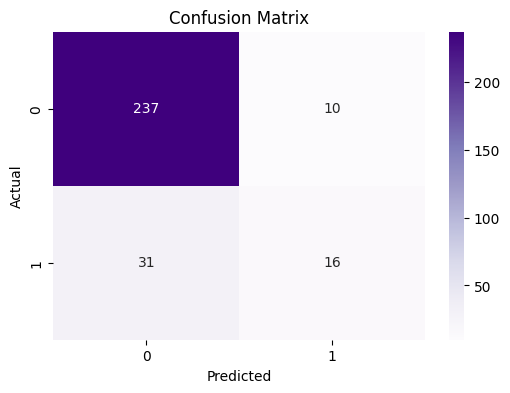

In [379]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the model correctly identified 237 employees who stayed and 16 employees who left, while 31 attrition cases were misclassified.

### Balanced Logistic Regression 

To address the class imbalance problem, Logistic Regression was trained using class_weight="balanced". This approach assigns higher importance to the minority class and aims to improve the detection of employee attrition cases.

Accuracy: 0.7517006802721088
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



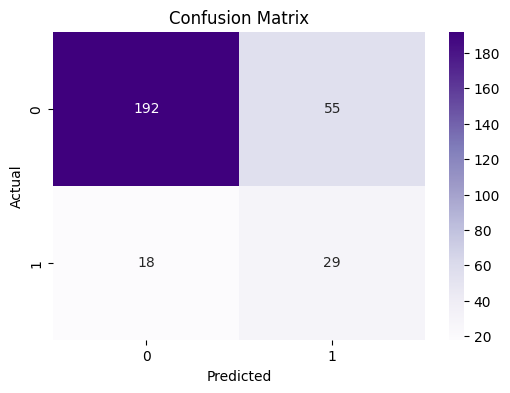

In [380]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train_scaled,y_train)

balanced_y_pred = balanced_model.predict(X_test_scaled)

balanced_accuracy = accuracy_score(
    y_test,
    balanced_y_pred
)

print("Accuracy:", balanced_accuracy)

balanced_cls = classification_report(
    y_test,
    balanced_y_pred
)

print(balanced_cls)


balanced_cm = confusion_matrix(
    y_test,
    balanced_y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Although the balanced model achieved lower overall accuracy, it substantially improved the recall of attrition cases from 34% to 62%. Since employee attrition detection is more important than maximizing overall accuracy, the balanced Logistic Regression model was considered more suitable for this business problem.

#### ROC-AUC Analysis

The ROC-AUC score was used to evaluate the model's ability to distinguish between employees who left and those who stayed. A higher AUC value indicates better classification performance across different decision thresholds.

In [381]:
balanced_y_prob = balanced_model.predict_proba(X_test_scaled)[:,1]

AUC Score: 0.7982599707123783


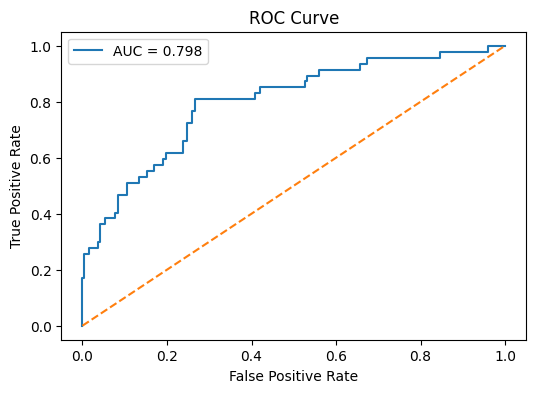

In [382]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    balanced_y_prob
)

auc_score = roc_auc_score(
    y_test,
    balanced_y_prob
)


print("AUC Score:", auc_score)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

The Balanced Logistic Regression model achieved an ROC-AUC score of 0.798, indicating a good ability to distinguish between employees who left the company and those who stayed. This result suggests that the model provides meaningful predictive power beyond random classification.

### Feature Importance Analysis

In [383]:
feature_importance = pd.DataFrame({
    "Feature" : X_train.columns,
    "Coefficient" : balanced_model.coef_[0]
})

feature_importance["Abs_Coefficient"] = abs(feature_importance["Coefficient"])

feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(10)


,Feature,Coefficient,Abs_Coefficient
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
16,TotalWorkingYears,-0.660270,0.660270
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
27,EducationField_Life Sciences,-0.512319,0.512319
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587


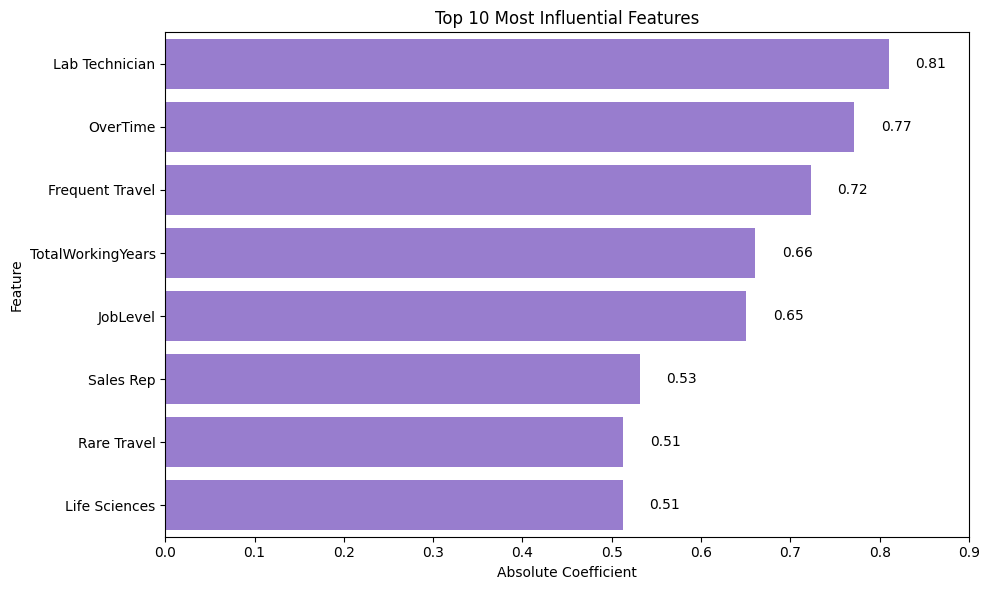

In [384]:
top_features = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
).head(8)

plt.figure(figsize=(10,6))

top_features["Feature"] = top_features["Feature"].replace({
    "JobRole_Laboratory Technician": "Lab Technician",
    "OverTime_Yes": "OverTime",
    "BusinessTravel_Travel_Frequently": "Frequent Travel",
    "BusinessTravel_Travel_Rarely": "Rare Travel",
    "JobRole_Sales Representative": "Sales Rep",
    "EducationField_Life Sciences": "Life Sciences",
    "YearsSinceLastPromotion": "Years Since Promotion",
    "Department_Sales": "Sales Department"
})

ax = sns.barplot(
    data=top_features,
    x="Abs_Coefficient",
    y="Feature",
    color="mediumpurple"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (
            p.get_width()+0.03,
            p.get_y()+p.get_height()/2
        ),
        va="center"
    )

plt.title("Top 10 Most Influential Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

ax.set_xlim(0, 0.9)

plt.tight_layout()
plt.show()

Feature importance analysis revealed that overtime, frequent business travel, and specific job roles such as Laboratory Technician and Sales Representative were among the strongest predictors of employee attrition. In contrast, employees with greater total working experience were less likely to leave the company. These findings suggest that workload, travel requirements, career stage, and job role characteristics play a significant role in employee retention.

### Random Forest Classifier

Random Forest was used as an ensemble learning method to improve predictive performance by combining multiple decision trees. The model was trained on the training dataset and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC metrics.

In [385]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

#### Random Forest Accuracy

In [386]:
rf_accuracy = accuracy_score(
    y_test,
    rf_y_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.826530612244898


The Random Forest model achieved an accuracy score of 82.6%, indicating strong overall classification performance.

#### Random Forest Classification Report 

In [387]:
rf_cls = classification_report(
    y_test,
    rf_y_pred
)

print(rf_cls)

              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



Although the model achieved high precision and recall for employees who stayed, it identified only 9% of employees who actually left the company. This indicates poor performance in detecting attrition cases.

#### Random Fores Confusion Matrix

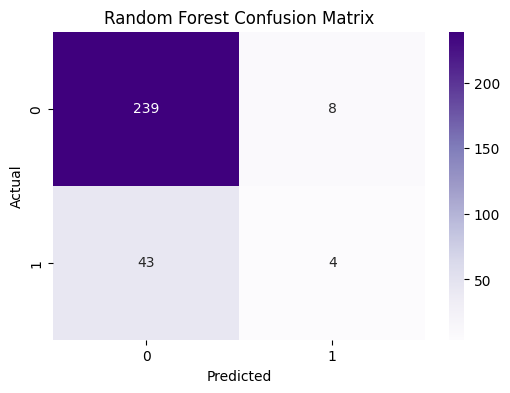

In [388]:
rf_cm = confusion_matrix(
    y_test,
    rf_y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

The confusion matrix shows that the model correctly identified 239 employees who stayed and only 4 employees who left. A large number of attrition cases were misclassified as non-attrition.

#### Random Forest ROC-AUC

In [389]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    rf_probs
)

print("AUC Score:", auc_score)

AUC Score: 0.8009303126884314


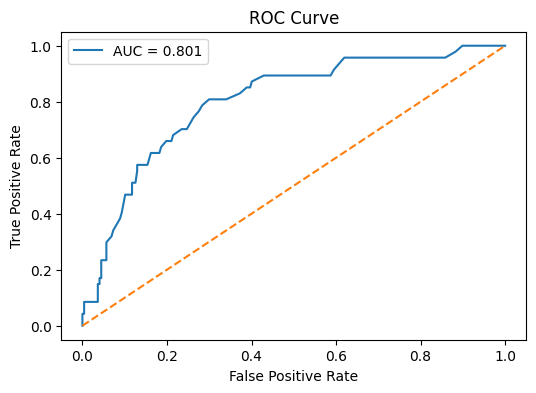

In [390]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC-AUC score of 0.80 indicates that the model has a good ability to distinguish between employees who stay and those who leave.

In [391]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
9,MonthlyIncome,0.073386
0,Age,0.066670
1,DailyRate,0.054236
16,TotalWorkingYears,0.052048
5,HourlyRate,0.047055
2,DistanceFromHome,0.046824
10,MonthlyRate,0.046283
19,YearsAtCompany,0.045568
43,OverTime_Yes,0.038507
11,NumCompaniesWorked,0.036292


Monthly Income, Age, Daily Rate, Total Working Years, and Overtime were identified as the most influential variables affecting employee attrition.

## # Model Comparison

The performance of Logistic Regression, Balanced Logistic Regression, and Random Forest models was compared using multiple evaluation metrics. Since employee attrition prediction is an imbalanced classification problem, special attention was given to recall performance for the attrition class.


In [395]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.86,
        0.75,
        0.83
    ],
    "Recall": [
        0.34,
        0.62,
        0.09
    ],
    "F1 Score": [
        0.44,
        0.44,
        0.14
    ],
    "ROC-AUC": [
        0.80,
        0.80,
        0.80
    ]
})

comparison = comparison.sort_values(
    by="Recall",
    ascending=False
)

comparison.style.highlight_max(
    subset=["Accuracy","Recall","F1 Score","ROC-AUC"],
    color="#A91CD8"
)


,Model,Accuracy,Recall,F1 Score,ROC-AUC
1,Balanced Logistic Regression,0.750000,0.620000,0.440000,0.800000
0,Logistic Regression,0.860000,0.340000,0.440000,0.800000
2,Random Forest,0.830000,0.090000,0.140000,0.800000


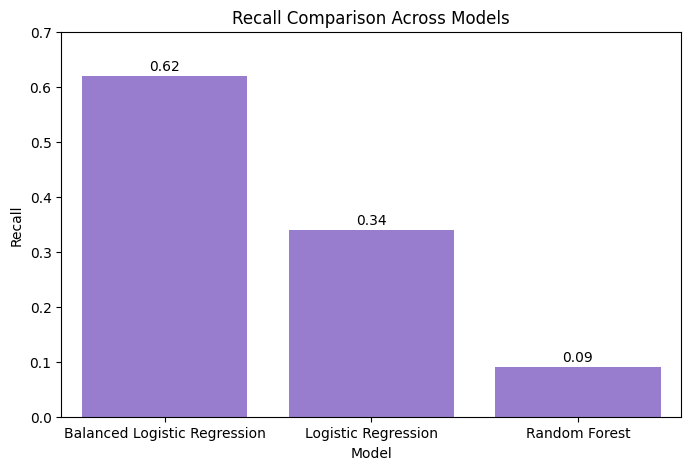

In [393]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="Recall",
    color="mediumpurple"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()+0.01
        ),
        ha="center"
    )

plt.title("Recall Comparison Across Models")
plt.ylabel("Recall")
plt.xlabel("Model")

plt.ylim(0, 0.7)

plt.show()

Although Logistic Regression achieved the highest accuracy, Balanced Logistic Regression provided the strongest recall performance for employee attrition cases. Since the primary business objective is to identify employees at risk of leaving, Balanced Logistic Regression was selected as the preferred model.

## Conclusion 

This project aimed to identify employees who are at risk of leaving the company and to understand the factors associated with employee attrition.

Exploratory data analysis revealed that attrition was more common among younger employees, single employees, employees who frequently traveled for business, and employees who worked overtime. Employees with lower job satisfaction and lower environment satisfaction also showed higher attrition rates.

A focused analysis on high-income and highly satisfied employees revealed that approximately 9% of these employees still left the company. Further investigation suggested that overtime, frequent business travel, long commuting distances, delayed promotions, and multiple previous employers may contribute to attrition even among employees who appear satisfied and well compensated.

Three machine learning models were evaluated: Logistic Regression, Balanced Logistic Regression, and Random Forest. Although Logistic Regression achieved the highest accuracy, Balanced Logistic Regression delivered the strongest recall performance for attrition cases. Since the primary objective was to identify employees at risk of leaving, Balanced Logistic Regression was selected as the preferred model.

Overall, the findings suggest that employee attrition is influenced by a combination of workload, career development opportunities, compensation, job role characteristics, and work-life balance factors.

 ## Business Recommendations

Based on the analysis results, several actions can be recommended to reduce employee attrition:

- Reduce excessive overtime by monitoring employee workload and promoting healthier work-life balance practices.
- Review business travel requirements, especially for employees who travel frequently.
- Improve career development opportunities by providing clear promotion paths and regular performance feedback.
- Pay special attention to high-risk job roles such as Laboratory Technicians and Sales Representatives.
- Implement retention programs for younger and single employees, who demonstrated higher attrition rates.
- Monitor employees who have experienced long periods without promotion and provide career growth discussions.
- Use the Balanced Logistic Regression model as an early warning system to identify employees at risk of leaving and proactively intervene before resignation occurs.

These actions may help organizations improve employee retention and reduce the costs associated with workforce turnover.